In [18]:
import numpy as np
import pandas as pd
import country_converter as coco
import matplotlib.pyplot as plt

# Checking the structure of the Data

In [2]:
df = pd.read_csv("../Data/Raw/Gdp_percap(2021 usd).csv")
print(df.head(10))

  iso3 Country  year       pop       rgdpe
0  ABW   Aruba  1970  0.058950  444.191925
1  ABW   Aruba  1971  0.058781  484.616943
2  ABW   Aruba  1972  0.058895  528.695312
3  ABW   Aruba  1973  0.059435  576.773071
4  ABW   Aruba  1974  0.060122  629.518372
5  ABW   Aruba  1975  0.060813  686.935852
6  ABW   Aruba  1976  0.061271  749.218506
7  ABW   Aruba  1977  0.061511  817.264404
8  ABW   Aruba  1978  0.061719  891.442261
9  ABW   Aruba  1979  0.061896  972.455750


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11201 entries, 0 to 11200
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   iso3     11201 non-null  object 
 1   Country  11201 non-null  object 
 2   year     11201 non-null  int64  
 3   pop      11201 non-null  float64
 4   rgdpe    11201 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 437.7+ KB


Data has the 5 columns and description for each column is per Data Documentation in DATA_NOTES.md. The data has no null values.

In [6]:
df.Country.nunique()

185

Data has 185 unique countries of data.

In [8]:
df['Country'].value_counts()

Country
Australia                    74
Argentina                    74
Brazil                       74
Belgium                      74
Austria                      74
                             ..
Turkmenistan                 34
Tajikistan                   34
Curaçao                      19
Sint Maarten (Dutch part)    19
South Sudan                  16
Name: count, Length: 185, dtype: int64

Each country has different year of data coverage.

# Prioratizing countries to comply with gini_index data

## Filtering Only interested countries.

In [3]:
# Master country list (114 from our full regional breakdown)
# Comment out / remove entries here to trim down to your target 114
COUNTRIES = [
    # North America
    "United States", "Canada", "Puerto Rico",
    # Western Europe
    "United Kingdom", "Germany", "France", "Ireland", "Belgium",
    "Netherlands", "Switzerland", "Luxembourg", "Austria",
    # Nordic
    "Sweden", "Norway", "Finland", "Denmark",
    # Southern Europe
    "Italy", "Portugal", "Spain", "Greece", "Cyprus",
    # Eastern Europe & Former Soviet
    "Hungary", "Poland", "Ukraine", "Uzbekistan", "Georgia", "Kyrgyzstan",
    "Slovenia", "Tajikistan", "Kazakhstan", "Moldova", "Estonia", "Belarus",
    "Armenia", "Croatia", "Lithuania", "Slovakia", "Czech Republic",
    "Latvia", "Russia", "Bulgaria", "Romania",
    # East Asia
    "Japan", "Taiwan", "Korea", "Hong Kong", "China",
    # South Asia
    "Pakistan", "India", "Bangladesh", "Sri Lanka", "Nepal",
    # Southeast Asia
    "Philippines", "Thailand", "Indonesia", "Malaysia", "Singapore",
    "Vietnam", "Laos",
    # Middle East & North Africa
    "Iran", "Israel", "Egypt", "Turkey", "Jordan", "Tunisia", "Morocco", "Qatar",
    # Sub-Saharan Africa
    "Madagascar", "Malawi", "Tanzania", "Sierra Leone", "South Africa",
    "Zambia", "Sudan", "Kenya", "Nigeria", "Rwanda", "Côte d'Ivoire",
    "Mauritania", "Lesotho", "Eswatini", "Guinea-Bissau", "Mauritius",
    "Mali", "Uganda", "Senegal", "Botswana", "Central African Republic",
    "Niger", "Ghana",
    # Latin America & Caribbean
    "Brazil", "Costa Rica", "Argentina", "Mexico", "Venezuela", "Chile",
    "Panama", "Colombia", "Peru", "Uruguay", "Guatemala",
    "Dominican Republic", "Barbados", "Honduras", "El Salvador", "Paraguay",
    "Trinidad and Tobago", "Jamaica", "Bolivia", "Ecuador",
    # Oceania
    "New Zealand", "Australia", "Fiji", "Tonga",
]

iso3_codes = coco.convert(names=COUNTRIES, to="ISO3", not_found=None)

# Apply filter to each dataset
df_filtered = df[df['iso3'].isin(iso3_codes)].copy()

# Flag any countries in your list that had ZERO matching rows in this dataset
missing = set(iso3_codes) - set(df_filtered['iso3'].unique())
if missing:
    print(f"⚠️ No data found for: {missing}")

⚠️ No data found for: {'PRI', 'TON'}


There are two countries of data that is not available in this dataset (Puerto Rico and Tonga).

## Mapping Region to each countries.

In [4]:
# Country -> Region mapping (112 countries, 12 regions)
REGION_MAP = {
    # North America
    "United States": "North America", "Canada": "North America",

    # Western Europe
    "United Kingdom": "Western Europe", "Germany": "Western Europe",
    "France": "Western Europe", "Ireland": "Western Europe",
    "Belgium": "Western Europe", "Netherlands": "Western Europe",
    "Switzerland": "Western Europe", "Luxembourg": "Western Europe",
    "Austria": "Western Europe",

    # Nordic
    "Sweden": "Nordic", "Norway": "Nordic",
    "Finland": "Nordic", "Denmark": "Nordic",

    # Southern Europe
    "Italy": "Southern Europe", "Portugal": "Southern Europe",
    "Spain": "Southern Europe", "Greece": "Southern Europe",
    "Cyprus": "Southern Europe",

    # Eastern Europe & Former Soviet
    "Hungary": "Eastern Europe & FSU", "Poland": "Eastern Europe & FSU",
    "Ukraine": "Eastern Europe & FSU", "Uzbekistan": "Eastern Europe & FSU",
    "Georgia": "Eastern Europe & FSU", "Kyrgyzstan": "Eastern Europe & FSU",
    "Slovenia": "Eastern Europe & FSU", "Tajikistan": "Eastern Europe & FSU",
    "Kazakhstan": "Eastern Europe & FSU", "Moldova": "Eastern Europe & FSU",
    "Estonia": "Eastern Europe & FSU", "Belarus": "Eastern Europe & FSU",
    "Armenia": "Eastern Europe & FSU", "Croatia": "Eastern Europe & FSU",
    "Lithuania": "Eastern Europe & FSU", "Slovakia": "Eastern Europe & FSU",
    "Czech Republic": "Eastern Europe & FSU", "Latvia": "Eastern Europe & FSU",
    "Russia": "Eastern Europe & FSU", "Bulgaria": "Eastern Europe & FSU",
    "Romania": "Eastern Europe & FSU",

    # East Asia
    "Japan": "East Asia", "Taiwan": "East Asia", "Korea": "East Asia",
    "Hong Kong": "East Asia", "China": "East Asia",

    # South Asia
    "Pakistan": "South Asia", "India": "South Asia",
    "Bangladesh": "South Asia", "Sri Lanka": "South Asia",
    "Nepal": "South Asia",

    # Southeast Asia
    "Philippines": "Southeast Asia", "Thailand": "Southeast Asia",
    "Indonesia": "Southeast Asia", "Malaysia": "Southeast Asia",
    "Singapore": "Southeast Asia", "Vietnam": "Southeast Asia",
    "Laos": "Southeast Asia",

    # Middle East & North Africa
    "Iran": "MENA", "Israel": "MENA", "Egypt": "MENA",
    "Turkey": "MENA", "Jordan": "MENA", "Tunisia": "MENA",
    "Morocco": "MENA", "Qatar": "MENA",

    # Sub-Saharan Africa
    "Madagascar": "Sub-Saharan Africa", "Malawi": "Sub-Saharan Africa",
    "Tanzania": "Sub-Saharan Africa", "Sierra Leone": "Sub-Saharan Africa",
    "South Africa": "Sub-Saharan Africa", "Zambia": "Sub-Saharan Africa",
    "Sudan": "Sub-Saharan Africa", "Kenya": "Sub-Saharan Africa",
    "Nigeria": "Sub-Saharan Africa", "Rwanda": "Sub-Saharan Africa",
    "Côte d'Ivoire": "Sub-Saharan Africa", "Mauritania": "Sub-Saharan Africa",
    "Lesotho": "Sub-Saharan Africa", "Eswatini": "Sub-Saharan Africa",
    "Guinea-Bissau": "Sub-Saharan Africa", "Mauritius": "Sub-Saharan Africa",
    "Mali": "Sub-Saharan Africa", "Uganda": "Sub-Saharan Africa",
    "Senegal": "Sub-Saharan Africa", "Botswana": "Sub-Saharan Africa",
    "Central African Republic": "Sub-Saharan Africa", "Niger": "Sub-Saharan Africa",
    "Ghana": "Sub-Saharan Africa",

    # Latin America & Caribbean
    "Brazil": "Latin America & Caribbean", "Costa Rica": "Latin America & Caribbean",
    "Argentina": "Latin America & Caribbean", "Mexico": "Latin America & Caribbean",
    "Venezuela": "Latin America & Caribbean", "Chile": "Latin America & Caribbean",
    "Panama": "Latin America & Caribbean", "Colombia": "Latin America & Caribbean",
    "Peru": "Latin America & Caribbean", "Uruguay": "Latin America & Caribbean",
    "Guatemala": "Latin America & Caribbean", "Dominican Republic": "Latin America & Caribbean",
    "Barbados": "Latin America & Caribbean", "Honduras": "Latin America & Caribbean",
    "El Salvador": "Latin America & Caribbean", "Paraguay": "Latin America & Caribbean",
    "Trinidad and Tobago": "Latin America & Caribbean", "Jamaica": "Latin America & Caribbean",
    "Bolivia": "Latin America & Caribbean", "Ecuador": "Latin America & Caribbean",

    # Oceania
    "New Zealand": "Oceania", "Australia": "Oceania",
    "Fiji": "Oceania",
}

# Step 1: pull out the country names (dict keys) as a list
country_names = list(REGION_MAP.keys())

# Step 2: convert all of them to ISO3 in one batch call
iso3_codes = coco.convert(names=country_names, to="ISO3", not_found="not found")

# Step 3: rebuild the dict with iso3 as the key, region as the value
iso3_region_dict = {
    iso3: REGION_MAP[name]
    for name, iso3 in zip(country_names, iso3_codes)
}

# --- Apply to dataframe ---
df_filtered['region'] = df_filtered['iso3'].map(iso3_region_dict)

# --- Validation: catch unmapped countries before they silently become NaN ---
unmapped = df_filtered.loc[df_filtered['region'].isna(), 'Country'].unique()
if len(unmapped) > 0:
    print(f"⚠️ {len(unmapped)} countries in the dataframe have no region assigned:")
    print(sorted(unmapped))
else:
    print("✅ All countries successfully mapped to a region.")

✅ All countries successfully mapped to a region.


# Adding a new column of gdp per capita (gdp_percap)

In [5]:
# Step 1: derive gdp per capita
df_filtered['gdp_per_capita'] = df_filtered['rgdpe'] / df_filtered['pop']

# Step 2: validate — catch silent NaN/inf before moving on
n_null = df_filtered['gdp_per_capita'].isna().sum()
n_inf = (df_filtered['gdp_per_capita'] == float('inf')).sum()
print(f"Null: {n_null}, Infinite: {n_inf}")

Null: 0, Infinite: 0


# Checking for inappropriate data points

## Calculating interquartile range for each country and extrcting those with outliers.

In [16]:
# Function to calculate interquartile range and outliers, returning data frame with outliers data points
def iqr_outliers_per_country(df, col):
    results = []
    for country, group in df.groupby('Country'):
        series = group[col].dropna()
        if len(series) < 4:  # too few points for a meaningful IQR
            continue
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        mask = (series < lower) | (series > upper)
        if mask.any():
            flagged = group.loc[series[mask].index, ['Country', 'year', col]]
            results.append(flagged)
    return pd.concat(results) if results else pd.DataFrame()

# Store countries with outliers in columns gdp_per_capita in separate variables.
outliers_by_country_gdp = iqr_outliers_per_country(df_filtered, 'gdp_per_capita')
country_gdp_outliers = set(outliers_by_country_gdp['Country'].unique())
print(country_gdp_outliers)

{'Colombia', 'Uganda', 'Nepal', 'India', 'Indonesia', 'Türkiye', 'Guatemala', "Côte d'Ivoire", 'Honduras', 'China', 'Mauritania', 'Dominican Republic', 'Switzerland', 'Panama', 'Romania', 'Sierra Leone', 'Tajikistan', 'Sri Lanka', 'Ecuador', 'El Salvador', 'Bolivia (Plurinational State of)', 'Peru', 'Uruguay', 'Ireland', 'Venezuela (Bolivarian Republic of)', 'Egypt', 'Senegal', 'Fiji', 'Bangladesh', 'Rwanda', 'U.R. of Tanzania: Mainland', 'Kenya', 'Costa Rica', 'Jordan', 'Sudan'}


## Investigating further to decide inappropriate data points for each flagged countries.

### Ploting plots for countries flagged for 'gdp_per_capita' column

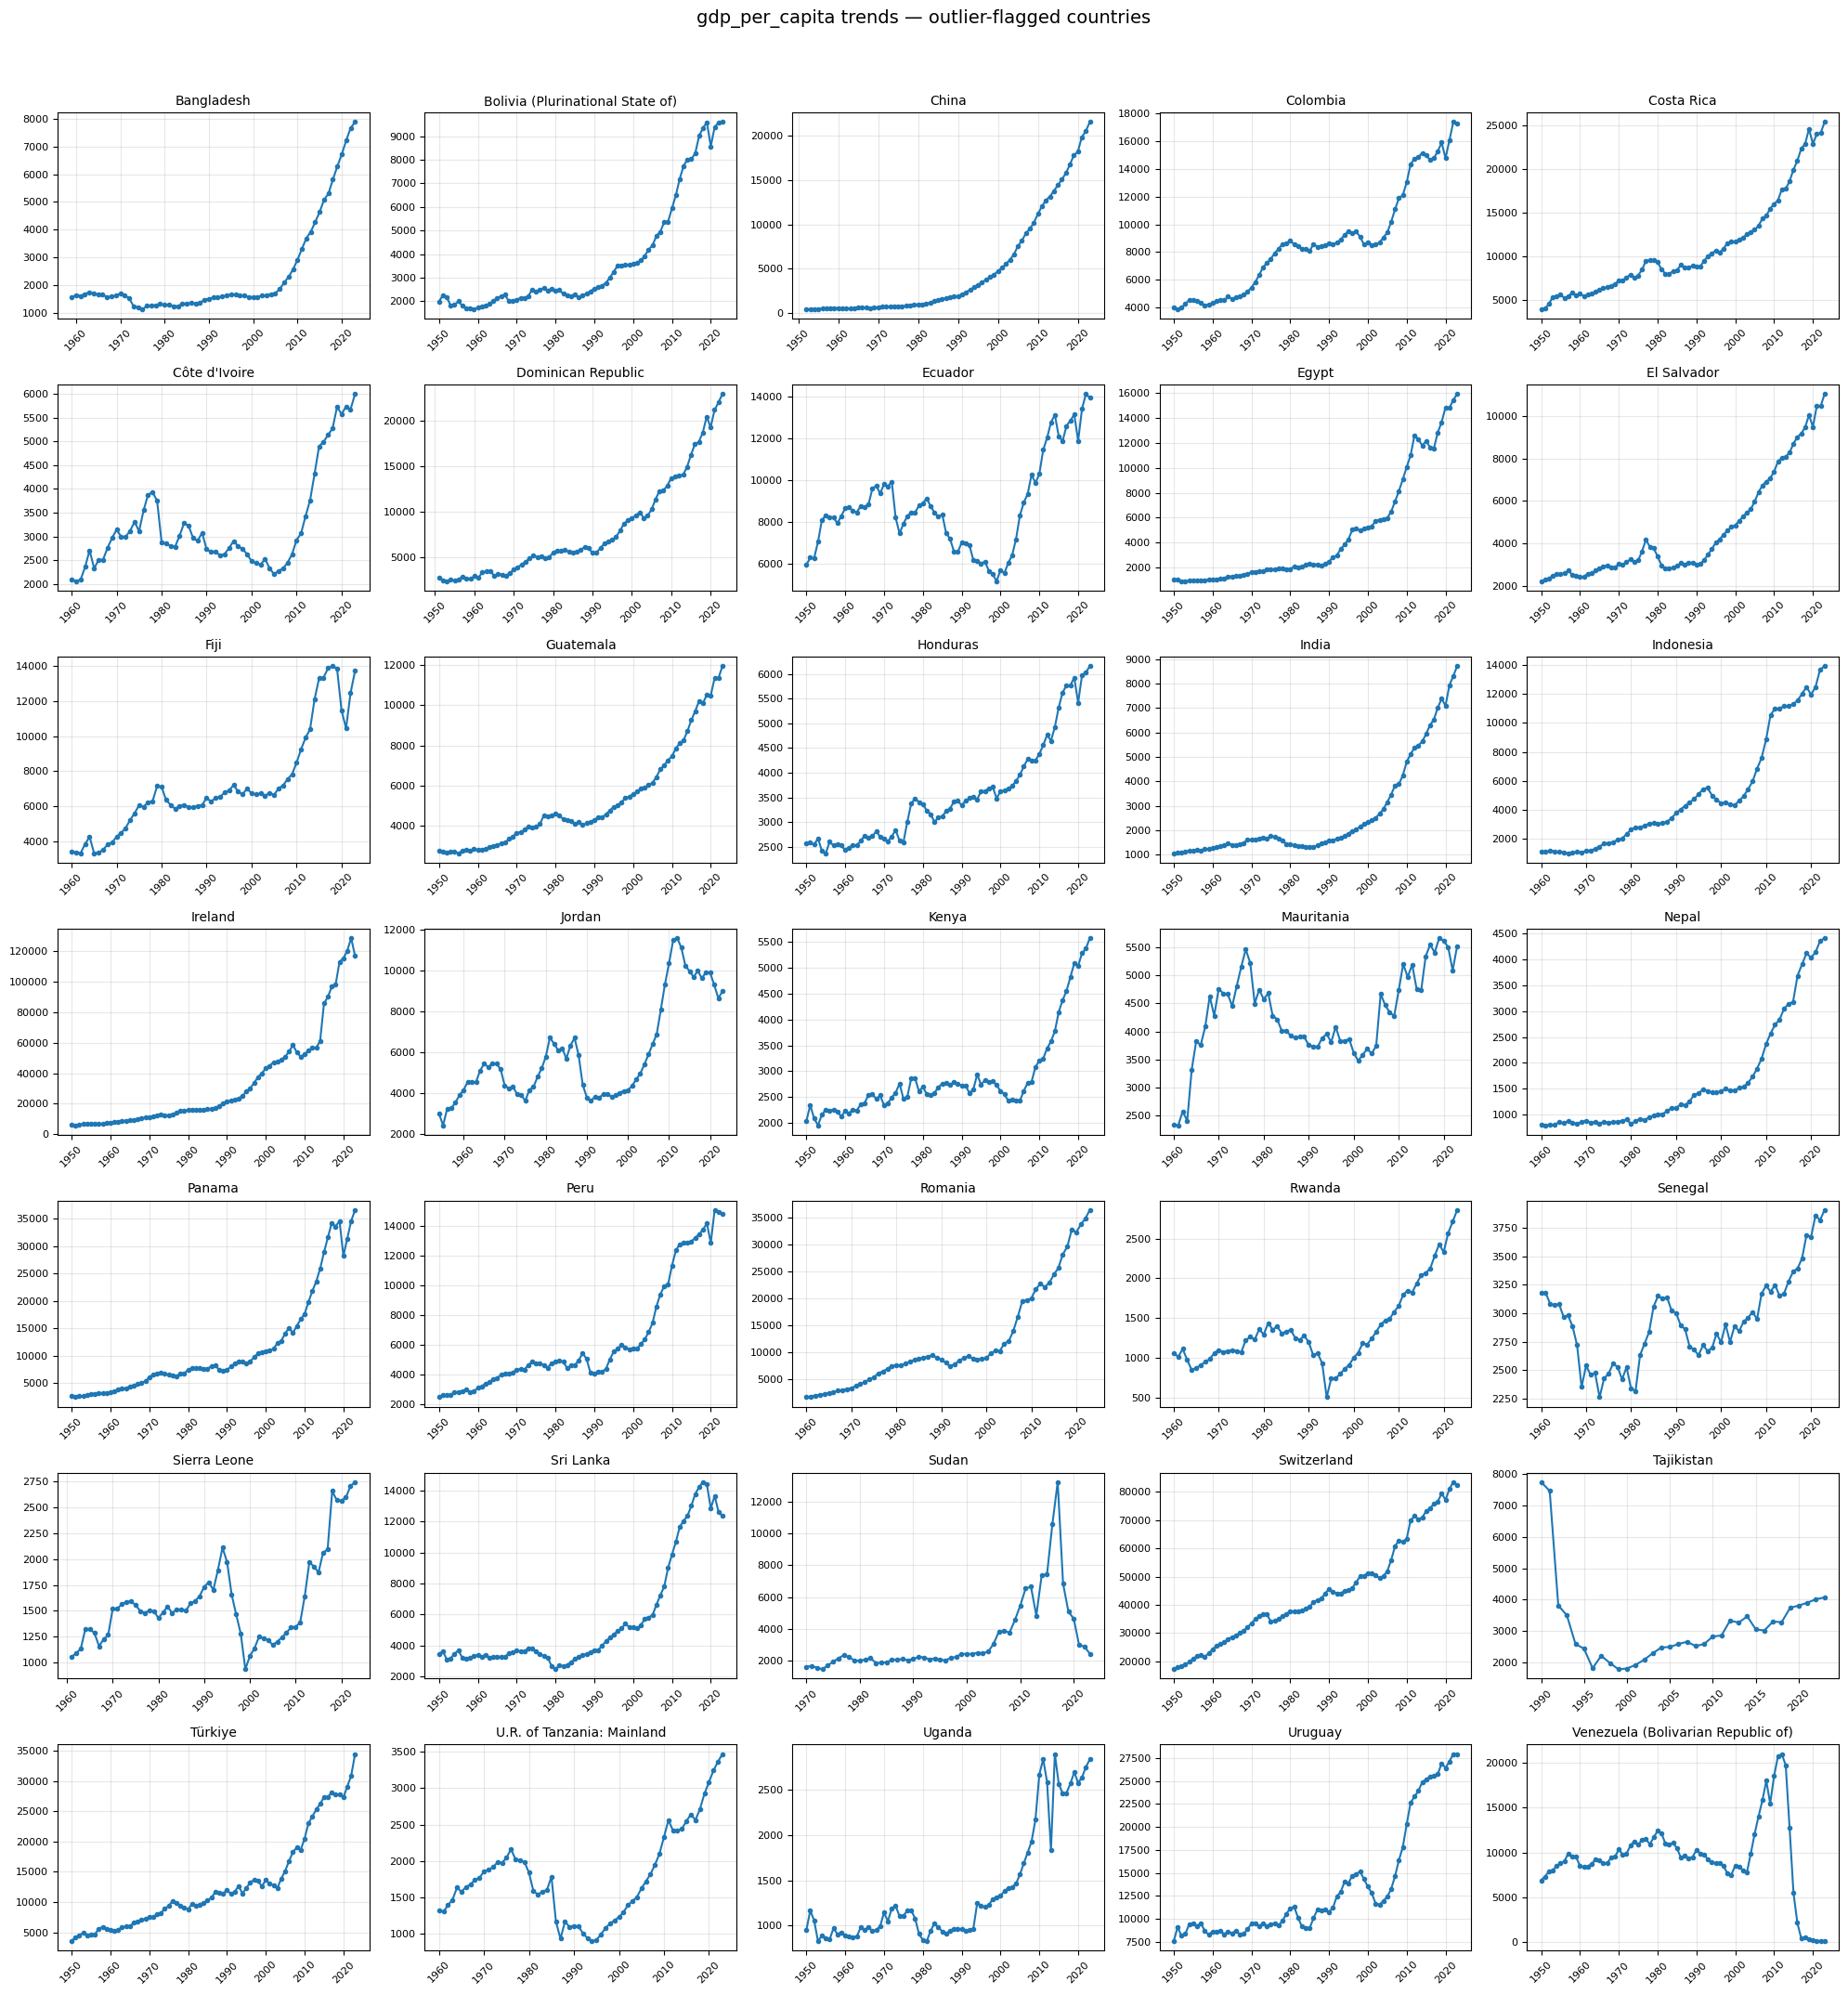

In [19]:
def plot_all_trends(df, countries, col='gdp_per_capita', cols_per_row=4):
    countries = sorted(countries)
    n = len(countries)
    n_rows = int(np.ceil(n / cols_per_row))

    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(cols_per_row * 4, n_rows * 3))
    axes = axes.flatten()  # makes indexing easy regardless of grid shape

    for i, country in enumerate(countries):
        subset = df[df['Country'] == country].sort_values('year')
        axes[i].plot(subset['year'], subset[col], marker='o', markersize=3)
        axes[i].set_title(country, fontsize=10)
        axes[i].tick_params(axis='x', rotation=45, labelsize=8)
        axes[i].tick_params(axis='y', labelsize=8)
        axes[i].grid(alpha=0.3)

    # Hide any unused subplot slots (if grid has more cells than countries)
    for j in range(n, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'{col} trends — outlier-flagged countries', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

plot_all_trends(df_filtered, country_gdp_outliers, col='gdp_per_capita', cols_per_row=5)

## Outlier Review — GDP per Capita (PWT)

Countries flagged by per-country IQR outlier detection (gdp_per_capita) were 
individually reviewed by plotting their full time series rather than removed automatically.

**Decision: No data points were dropped.**

Visual inspection showed that flagged values correspond to real, documented economic 
and political events rather than data entry errors — e.g. Ireland's 2015 "Leprechaun 
Economics" jump (multinational tax inversions relocating IP assets on paper), South 
Sudan's 2011 independence splitting Sudan's series, and Venezuela's mid-2010s 
hyperinflation and economic collapse. These reflect real, well-documented economic 
history rather than noise, and are consistent with the project's focus on divergence 
and structural change over time.

Outlier detection was therefore used as a review checkpoint, not an automatic filter.